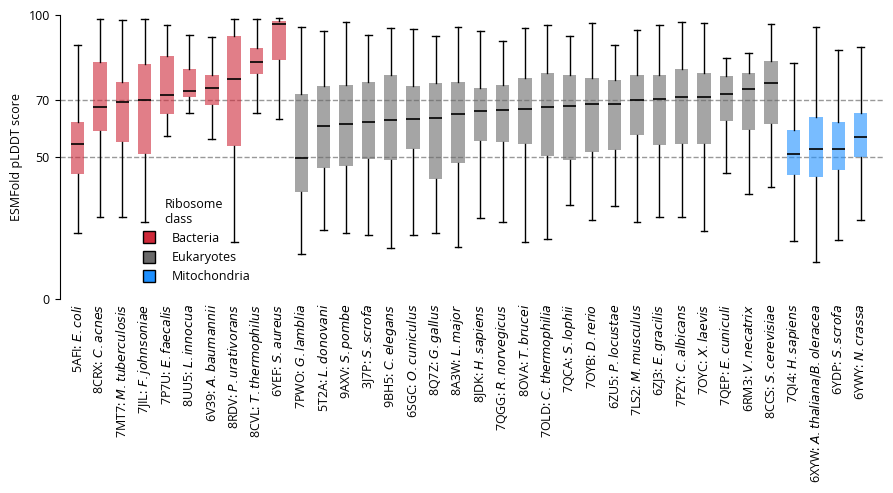

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from Bio.PDB import PDBParser

matplotlib.rcParams["font.size"] = 9
matplotlib.rcParams["font.family"] = "Open Sans"

BASE_DIR = ".."
PREDICTED_PDBS_DIR = f"{BASE_DIR}/PREDICTED_PDBS"
RESULTS_PLDDT_DIR = f"{BASE_DIR}/RESULTS_PLDDT"
PLOT_DIR = f"{BASE_DIR}/PLOTS"
MIN_LENGTH = 20

RIBOSOME_CLASS_COLORS = {
    "bacteria": "#CE2939",
    "eukaryotes": "#696969",
    "mitochondria": "#1E90FF",
}

AA_3TO1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "SEC": "U", "PYL": "O",
}

def load_chain_sequence(pdb_id, chain_id):
    pdb_path = f"{PREDICTED_PDBS_DIR}/{pdb_id}/{chain_id}.pdb"
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(chain_id, pdb_path)
    model = structure[0]
    residues = [r for r in model.get_residues() if r.id[0] == " "]
    return [AA_3TO1[r.resname] for r in residues if r.resname in AA_3TO1]

def find_fragment_start(fpf_sequence, chain_seq):
    return "".join(chain_seq).find(fpf_sequence)

with open(f"{BASE_DIR}/ribosome_info.json") as f:
    ribosome_info = json.load(f)

with open(f"{BASE_DIR}/fpf_info.json") as f:
    fpf_info = json.load(f)

ribosome_data = []

for entry in ribosome_info:
    pdb_id = entry["pdb_id"].upper()
    ribosome_class = entry["ribosome_class"]

    fragments = fpf_info.get(pdb_id, [])
    fragments = [f for f in fragments if f["length"] >= MIN_LENGTH]
    if not fragments:
        continue

    chain_seq_cache = {}
    all_plddt = []

    for frag in fragments:
        chain_id = frag["chain_name"]
        fpf_seq = frag["sequence"]

        plddt_path = f"{RESULTS_PLDDT_DIR}/{pdb_id}/{chain_id}_plddt.npy"
        if not os.path.exists(plddt_path):
            continue

        if chain_id not in chain_seq_cache:
            chain_seq_cache[chain_id] = load_chain_sequence(pdb_id, chain_id)
        chain_seq = chain_seq_cache[chain_id]

        start_idx = find_fragment_start(fpf_seq, chain_seq)
        if start_idx == -1:
            continue

        plddt = np.load(plddt_path) * 100
        extracted = plddt[start_idx : start_idx + len(fpf_seq)]
        extracted = extracted[~np.isnan(extracted)]
        all_plddt.extend(extracted)

    if all_plddt:
        ribosome_data.append({
            "pdb_id": pdb_id,
            "organism": entry["organism"],
            "ribosome_class": ribosome_class,
            "plddt_values": all_plddt,
            "median_plddt": np.median(all_plddt),
        })

domain_order = ["bacteria", "eukaryotes", "mitochondria"][::-1]

ribosome_data.sort(key=lambda x: (
    domain_order.index(x["ribosome_class"]) if x["ribosome_class"] in domain_order else 99,
    -x["median_plddt"]
), reverse=True)

labels = [f"{rd['pdb_id']}: $\\mathit{{{rd['organism']}}}$" for rd in ribosome_data]
label_colors = [RIBOSOME_CLASS_COLORS.get(rd["ribosome_class"], "#808080") for rd in ribosome_data]
plddt_values_per_ribosome = [rd["plddt_values"] for rd in ribosome_data]

n = len(ribosome_data)
x = np.arange(n)

fig, ax = plt.subplots(figsize=(9, 5))

boxplot = ax.boxplot(
    plddt_values_per_ribosome,
    positions=x,
    vert=True,
    patch_artist=True,
    widths=0.6,
    medianprops=dict(color="black", linewidth=1.2),
    flierprops=dict(marker="o", markersize=3, alpha=0.3, markeredgecolor="none")
)

for box, color in zip(boxplot["boxes"], label_colors):
    box.set_facecolor(color)
    box.set_alpha(0.6)
    box.set_edgecolor("none")

ax.set_xlim(-0.8, n)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)

ax.set_ylabel("ESMFold pLDDT score")
ax.set_ylim(0, 100)
ax.axhline(y=70, color="gray", linestyle="--", linewidth=1, alpha=0.8, zorder=1)
ax.axhline(y=50, color="gray", linestyle="--", linewidth=1, alpha=0.8, zorder=1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="x", length=0)
ax.set_yticks([0, 50, 70, 100])

domain_handles = [
    plt.Line2D([0], [0], marker="s", color="none",
               markerfacecolor=RIBOSOME_CLASS_COLORS[d], markersize=8,
               label=d.capitalize())
    for d in domain_order if d in RIBOSOME_CLASS_COLORS
]
ax.legend(
    handles=domain_handles[::-1],
    title="Ribosome\nclass",
    loc="lower left",
    frameon=False,
    bbox_to_anchor=(0.08, 0.015)
)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/plddt.png", dpi=300, bbox_inches="tight")